# **1- Imports**

In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import BertTokenizer, BertModel
from transformers import get_linear_schedule_with_warmup
from torch.optim import AdamW
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, f1_score,
                             roc_auc_score, classification_report)
import matplotlib.pyplot as plt
import re

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Appareil utilisé : {device}")

Appareil utilisé : cuda


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import BertTokenizer, BertModel
from transformers import get_linear_schedule_with_warmup
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from urllib.parse import urlparse

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [4]:
# monter drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
MBFC_CREDIBILITY_DB = {
    # --- Sources FIABLES (score élevé) ---
    "reuters.com":          {"score": 0.95, "bias": "center",       "category": "reliable"},
    "apnews.com":           {"score": 0.95, "bias": "center",       "category": "reliable"},
    "bbc.com":              {"score": 0.90, "bias": "center-left",  "category": "reliable"},
    "theguardian.com":      {"score": 0.85, "bias": "center-left",  "category": "reliable"},
    "nytimes.com":          {"score": 0.85, "bias": "center-left",  "category": "reliable"},
    "washingtonpost.com":   {"score": 0.85, "bias": "center-left",  "category": "reliable"},
    "npr.org":              {"score": 0.88, "bias": "center-left",  "category": "reliable"},
    "politifact.com":       {"score": 0.92, "bias": "center",       "category": "fact-checker"},
    "snopes.com":           {"score": 0.90, "bias": "center-left",  "category": "fact-checker"},
    "usatoday.com":         {"score": 0.80, "bias": "center",       "category": "reliable"},
    "cbsnews.com":          {"score": 0.82, "bias": "center-left",  "category": "reliable"},
    "nbcnews.com":          {"score": 0.80, "bias": "center-left",  "category": "reliable"},
    "abcnews.go.com":       {"score": 0.80, "bias": "center-left",  "category": "reliable"},

    # --- Sources MIXTES (score moyen) ---
    "foxnews.com":          {"score": 0.45, "bias": "right",        "category": "mixed"},
    "dailymail.co.uk":      {"score": 0.40, "bias": "right",        "category": "mixed"},
    "nypost.com":           {"score": 0.42, "bias": "right-center", "category": "mixed"},
    "huffpost.com":         {"score": 0.55, "bias": "left",         "category": "mixed"},
    "salon.com":            {"score": 0.50, "bias": "left",         "category": "mixed"},
    "thehill.com":          {"score": 0.65, "bias": "center",       "category": "mixed"},

    # --- Sources PEU FIABLES (score bas) ---
    "breitbart.com":        {"score": 0.10, "bias": "extreme-right","category": "fake"},
    "infowars.com":         {"score": 0.05, "bias": "extreme-right","category": "fake"},
    "naturalnews.com":      {"score": 0.05, "bias": "extreme-right","category": "fake"},
    "beforeitsnews.com":    {"score": 0.08, "bias": "conspiracy",   "category": "fake"},
    "worldnewsdailyreport.com": {"score": 0.02, "bias": "fake",    "category": "fake"},
    "empirenews.net":       {"score": 0.03, "bias": "fake",         "category": "fake"},
    "abcnews.com.co":       {"score": 0.02, "bias": "fake",         "category": "fake"},
    "politicot.com":        {"score": 0.05, "bias": "fake",         "category": "fake"},
    "newslo.com":           {"score": 0.08, "bias": "fake",         "category": "fake"},
    "thelastlineofdefense.org": {"score": 0.03, "bias": "fake",    "category": "fake"},
}

In [6]:
DEFAULT_SCORE= 0.5
DEFAULT_INFO = {"score": DEFAULT_SCORE, "bias": "unknown", "category": "unknown"}

def extract_domain(url_or_sourse):
  """
  Extraire le domaine d'une URL.
  """

  if not isinstance(url_or_sourse,str):
    return "unknown"

  if url_or_sourse.startswith("http"):
    parsed= urlparse(url_or_sourse)
    domain= parsed.netloc.replace("www.","")
    return domain

  if "." in url_or_sourse:
    return url_or_sourse.replace("www","")

  return  url_or_sourse

In [7]:
domain = extract_domain("https://km-news.net/")
print(domain)

km-news.net


#### **Score MFBC**

In [8]:
def get_mbfc_score(domain):
  """
  Retourne les infos de rédibilité MBFC du nom de domaine.
  Si le domain n'existe pas, retourne les infos par défaut.
  """
  domain= domain.lower().strip()

  #Chercher le domaine exact d'abord
  if domain in MBFC_CREDIBILITY_DB:
    return MBFC_CREDIBILITY_DB[domain]

  #Chercher une correspondance partielle

  for known_domain, info in MBFC_CREDIBILITY_DB.items():
    if known_domain in domain or domain in known_domain:
      return info

  #Pas de correspondance trouvée
  return DEFAULT_INFO

In [9]:
info = get_mbfc_score("breitbart.com")
print(info)

{'score': 0.1, 'bias': 'extreme-right', 'category': 'fake'}


In [10]:
df= pd.read_csv("/content/drive/MyDrive/fakenewsnet_full_clean_valid_only.csv")
print(df['source'].value_counts())

source
gossipcop     10763
politifact      182
Name: count, dtype: int64


In [11]:
# 1. Filtrer pour garder uniquement 'gossipcop'
df_gossip = df[df['source'] == 'gossipcop']

# 2. Enregistrer dans un NOUVEAU fichier (sans écraser l'ancien)
df_gossip.to_csv("/content/drive/MyDrive/fakenewsnet_gossipcop_only.csv", index=False)

# Vérification du nombre de lignes
print(f"Fichier original préservé. Nouveau fichier créé avec {len(df_gossip)} lignes.")


Fichier original préservé. Nouveau fichier créé avec 10763 lignes.


# **FEATURES COMPORTEMENTALES**

- (extraites directement du texte/titre de l'article)

- Ces features capturent le STYLE d'écriture de la source,
- indépendamment du contenu factuel.
- Vocabulaire "choc" souvent utilisé dans les fake news

In [12]:
SENSATIONAL_WORDS = [
    "shocking", "unbelievable", "breaking", "exclusive", "bombshell",
    "outrage", "scandal", "exposed", "revealed", "secret", "conspiracy",
    "urgent", "alert", "warning", "crisis", "disaster", "chaos",
    "incredible", "stunning", "explosive", "miracle", "banned",
    "censored", "truth", "wake up", "they don't want you to know"
]

In [13]:
def compute_behavioral_features(title, text=""):
    """
    Calcule 4 features comportementales à partir du titre et du texte.

    Retourne un dictionnaire avec :
    - ratio_uppercase   : proportion de lettres en majuscules (sensationnalisme)
    - exclamation_score : densité de points d'exclamation
    - sensational_score : proportion de mots "choc"
    - external_links    : nombre de liens externes (crédibilité)
    """
    if not isinstance(title, str):
      title= ""
    if not isinstance(text,str):
      text= ""


    full_text= title + " " + text

    # Feature 1 : Ration en Majuscule car les fake utilise beaucoup les majuscules

    if len(title)> 0:
      n_uppercase = sum(1 for c in title if c.isupper())
      nb_letters = sum(1 for c in title if c.isalpha())
      ratio_uppercase = n_uppercase / nb_letters
    else:
      n_uppercase = 0.0

    #Feature 2 : les exclamation car les FAKE utilisent beaucoups les points d'exclamation

    nb_exclamations = full_text.count("!") + full_text.count("?")
    nb_words= len(full_text.split())
    exclamation_score = nb_exclamations / nb_words
    #Feature 3 : Sentsationalisme. Proportion de mots choc
    full_text_lower = full_text.lower()
    nb_sensational = sum(
        1 for word in SENSATIONAL_WORDS
        if word in full_text_lower
    )

    sensational_score = nb_sensational / len(SENSATIONAL_WORDS)

    #Feature 4 : Nombre de liens externes. Les cites fiables cient toujours leurs sources
    nb_links = len(re.findall(r'http[s]?://\S+', text))
    #On normalise : on plafonne à 10 liens
    external_links_norm= min(nb_links / 10, 1.0)

    return {
        "ratio_uppercase": round(ratio_uppercase,4),
        "exclamation_score": round(exclamation_score, 4),
        "sensational_score": round(sensational_score, 4),
        "external_links": round(external_links_norm,4)
    }

### **Vecteur source final**

In [14]:
def compute_source_vector(domain_or_url, title, text=""):
    """
    Fonction principale du Module 2.

    Combine le score MBFC et les features comportementales
    pour produire un vecteur source de 5 dimensions.

    Paramètres :
        domain_or_url : str  → URL ou nom de domaine de la source
        title         : str  → Titre de l'article
        text          : str  → Corps de l'article (optionnel)

    Retourne :
        np.array de shape (5,) contenant :
        [mbfc_score, ratio_uppercase, exclamation_score,
         sensational_score, external_links]
    """

    #Score MBFC
    domain= extract_domain(domain_or_url)
    mbfc_info = get_mbfc_score(domain)
    mbfc_score = mbfc_info["score"]

    #FEATURES COMPORTEMENTALES
    behav = compute_behavioral_features(title, text)

    #Construction du vecteur final
    source_vector = np.array([
        mbfc_score,
        behav["ratio_uppercase"],
        behav["exclamation_score"],
        behav["sensational_score"],
        behav["external_links"]
    ], dtype=np.float32)

    return source_vector, mbfc_info, behav

In [17]:
# ============================================================
# CHARGEMENT  — avec domain depuis url
# ============================================================

import pandas as pd
import numpy as np
from urllib.parse import urlparse

def load_fakenewsnet_fixed(filepath):
    """
    """
    df = pd.read_csv(filepath)
    print(f"Colonnes : {df.columns.tolist()}")

    # --- Ajout du domaine si absent ---
    if 'domain' not in df.columns:
        def extract_domain(url):
            try:
                url = str(url).strip()
                if not url.startswith('http'):
                    url = 'http://' + url
                domain = urlparse(url).netloc.replace('www.', '').strip()
                return domain if domain and domain != 'nan' else 'unknown'
            except:
                return 'unknown'
        df['domain'] = df['url'].apply(extract_domain)
        print(f"✅ Colonne 'domain' créée depuis 'url'")

    # --- Nettoyage ---
    df['title']  = df['title'].fillna('')
    df['text']   = df['text'].fillna('')
    df['domain'] = df['domain'].fillna('unknown').replace('nan', 'unknown')
    df = df.dropna(subset=['label']).reset_index(drop=True)

    # --- Contenu combiné titre + 100 premiers mots du texte ---
    df['content'] = (
        df['title'] + ' ' +
        df['text'].apply(lambda t: ' '.join(str(t).split()[:100]))
    ).str.strip()

    texts   = df['content'].tolist()
    labels  = df['label'].astype(int).tolist()
    domains = df['domain'].tolist()
    titles  = df['title'].tolist()
    bodies  = df['text'].tolist()

    # --- Vecteurs sources ---
    print("Calcul des vecteurs sources (Module 2)...")
    source_vectors = []
    for domain, title, text in zip(domains, titles, bodies):
        vec, _, _ = compute_source_vector(domain, title, text)
        source_vectors.append(vec)
    source_vectors = np.vstack(source_vectors)  # (N, 5)

    print(f"Dataset chargé      : {len(texts)} articles")
    print(f"Vecteurs sources    : {source_vectors.shape}")
    print(f"Distribution labels : {pd.Series(labels).value_counts().to_dict()}")
    print(f"Top domaines        : {pd.Series(domains).value_counts().head(5).to_dict()}")

    return texts, source_vectors, labels


# Remplace l'appel dans la pipeline
DATASET_PATH  = '/content/drive/MyDrive/fakenewsnet_gossipcop_balanced.csv'
texts, source_vectors, labels = load_fakenewsnet_fixed(DATASET_PATH)

Colonnes : ['id', 'title', 'text', 'source', 'label', 'url', 'has_text', 'text_length']
✅ Colonne 'domain' créée depuis 'url'
Calcul des vecteurs sources (Module 2)...
Dataset chargé      : 5152 articles
Vecteurs sources    : (5152, 5)
Distribution labels : {1: 2576, 0: 2576}
Top domaines        : {'dailymail.co.uk': 414, 'usmagazine.com': 317, 'etonline.com': 246, 'radaronline.com': 169, 'eonline.com': 142}


# **ÉTAPE A — DATASET COMBINÉ**

In [18]:
class HybridDataset(Dataset):
  """
  Dataset qui prépare les deux types d'entrée pour notre modèle :
    - Les tokens BERT pour le texte (Module 1)
    - Le vecteur source pour la crédibilité (Module 2)
  """
  def __init__(self, texts, source_vectors, labels, tokenizer, max_length= 256):
    self.texts = texts
    self.source_vectors = source_vectors
    self.labels = labels
    self.tokenizer = tokenizer
    self.max_length = max_length

  def __len__(self):
    return len(self.texts)

  def __getitem__(self, idx):
    text = str(self.texts[idx])
    label = self.labels[idx]
    src_vec = self.source_vectors[idx]
    encoding = self.tokenizer(
        text,
        max_length= self.max_length,
        padding= 'max_length',
        truncation= True,
        return_tensors= 'pt'
    )

    return {
        'input_ids':      encoding['input_ids'].squeeze(),
        'attention_mask': encoding['attention_mask'].squeeze(),
        'source_vector':  torch.tensor(src_vec, dtype=torch.float32),
        'label':          torch.tensor(label, dtype=torch.long)
        }

# **ÉTAPE B - MODÈLE HYBRIDE**
CHANGEMENT : source_dim=4 par défaut

In [19]:
class HybridFakeNewsDetector(nn.Module):
    def __init__(self, bert_model_name='bert-base-uncased',
                 source_dim=5,
                 hidden_dim=256,
                 num_classes=2,
                 dropout=0.3):
        super(HybridFakeNewsDetector, self).__init__()

        self.bert = BertModel.from_pretrained(bert_model_name)
        bert_hidden = self.bert.config.hidden_size  # 768

        # Encodeur source : [5] → [32]
        self.source_encoder = nn.Sequential(
            nn.Linear(source_dim, 32),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(32, 32),
            nn.ReLU()
        )

        # Fusion : 768 + 32 = 800
        fusion_dim = bert_hidden + 32

        self.classifier = nn.Sequential(
            nn.Linear(fusion_dim, hidden_dim),  # 800 → 256
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, 64),          # 256 → 64
            nn.ReLU(),
            nn.Dropout(dropout / 2),
            nn.Linear(64, num_classes)          # 64 → 2
        )

    def forward(self, input_ids, attention_mask, source_vector):
        bert_output    = self.bert(input_ids=input_ids,
                                   attention_mask=attention_mask)
        cls_vector     = bert_output.last_hidden_state[:, 0, :]  # (batch, 768)
        source_encoded = self.source_encoder(source_vector)       # (batch, 32)
        fused          = torch.cat([cls_vector, source_encoded], dim=1)  # (batch, 800)
        return self.classifier(fused)


# **ÉTAPE C : FONCTIONS ENTRAÎNEMENT / ÉVALUATION**

In [20]:
def train_epoch(model, loader, optimizer, scheduler, device):
    model.train()
    total_loss = 0
    all_preds, all_labels = [], []
    criterion = nn.CrossEntropyLoss()

    for batch in loader:
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        source_vector  = batch['source_vector'].to(device)
        labels         = batch['label'].to(device)

        optimizer.zero_grad()
        logits = model(input_ids, attention_mask, source_vector)
        loss   = criterion(logits, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()

        total_loss += loss.item()
        preds = torch.argmax(logits, dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.cpu().numpy())

    return total_loss / len(loader), accuracy_score(all_labels, all_preds)


def evaluate(model, loader, device):
    model.eval()
    total_loss = 0
    all_preds, all_labels, all_probs = [], [], []
    criterion = nn.CrossEntropyLoss()

    with torch.no_grad():
        for batch in loader:
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            source_vector  = batch['source_vector'].to(device)
            labels         = batch['label'].to(device)

            logits = model(input_ids, attention_mask, source_vector)
            loss   = criterion(logits, labels)
            total_loss += loss.item()

            probs = torch.softmax(logits, dim=1)[:, 1].cpu().numpy()
            preds = torch.argmax(logits, dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs)

    acc = accuracy_score(all_labels, all_preds)
    f1  = f1_score(all_labels, all_preds, average='weighted')
    auc = roc_auc_score(all_labels, all_probs)
    return total_loss / len(loader), acc, f1, auc, all_preds, all_labels


# **ÉTAPE E : PIPELINE PRINCIPALE**
✅ CHANGEMENT : DATASET_PATH mis à jour

# **rééquilibrage du dataset**

In [21]:
# ============================================================
# FIX — Rééquilibrage du dataset GossipCop
# ============================================================

import pandas as pd
import numpy as np
from urllib.parse import urlparse

df = pd.read_csv('/content/drive/MyDrive/fakenewsnet_gossipcop_only.csv')

print("Avant rééquilibrage :")
print(df['label'].value_counts())

# Undersampling de la classe majoritaire
df_fake = df[df['label'] == 1]
df_real = df[df['label'] == 0]

# On réduit les "réels" au nombre de "fakes"
df_real_sampled = df_real.sample(n=len(df_fake), random_state=42)
df_balanced = pd.concat([df_fake, df_real_sampled], ignore_index=True)
df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"\nAprès rééquilibrage :")
print(df_balanced['label'].value_counts())
print(f"Total : {len(df_balanced)} articles")

# Sauvegarde
df_balanced.to_csv('/content/drive/MyDrive/fakenewsnet_gossipcop_balanced.csv', index=False)
print("\n✅ Sauvegardé dans 'fakenewsnet_gossipcop_balanced.csv'")

Avant rééquilibrage :
label
0    8187
1    2576
Name: count, dtype: int64

Après rééquilibrage :
label
1    2576
0    2576
Name: count, dtype: int64
Total : 5152 articles

✅ Sauvegardé dans 'fakenewsnet_gossipcop_balanced.csv'


Colonnes : ['id', 'title', 'text', 'source', 'label', 'url', 'has_text', 'text_length']
✅ Colonne 'domain' créée depuis 'url'
Calcul des vecteurs sources (Module 2)...
Dataset chargé      : 5152 articles
Vecteurs sources    : (5152, 5)
Distribution labels : {1: 2576, 0: 2576}
Top domaines        : {'dailymail.co.uk': 414, 'usmagazine.com': 317, 'etonline.com': 246, 'radaronline.com': 169, 'eonline.com': 142}
Train : 4121 | Test : 1031


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Paramètres du modèle : 109,705,122

=== ENTRAÎNEMENT FUSION MODULE 1 + MODULE 2 ===

--- Époque 1/3 ---
Train → Loss: 0.6071 | Acc: 0.6612
Test  → Loss: 0.4651  | Acc: 0.7818 | F1: 0.7818 | AUC: 0.8772

--- Époque 2/3 ---
Train → Loss: 0.4337 | Acc: 0.8170
Test  → Loss: 0.4560  | Acc: 0.7915 | F1: 0.7894 | AUC: 0.8940

--- Époque 3/3 ---
Train → Loss: 0.3278 | Acc: 0.8796
Test  → Loss: 0.4476  | Acc: 0.8118 | F1: 0.8118 | AUC: 0.8929

=== ÉVALUATION FINALE ===

              precision    recall  f1-score   support

        Réel       0.81      0.82      0.81       516
        Fake       0.82      0.80      0.81       515

    accuracy                           0.81      1031
   macro avg       0.81      0.81      0.81      1031
weighted avg       0.81      0.81      0.81      1031

Accuracy : 0.8118 | F1 : 0.8118 | AUC : 0.8929


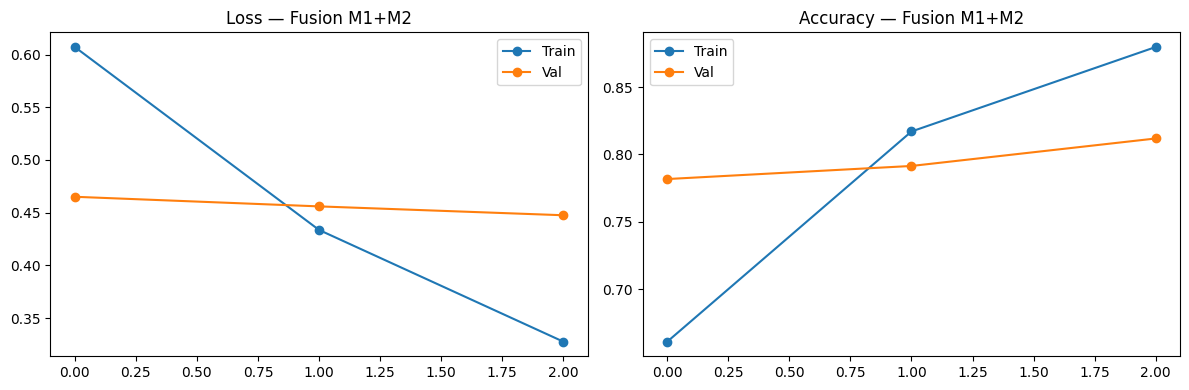

Courbes sauvegardées dans 'fusion_m1_m2_curves.png'
Modèle sauvegardé dans 'fusion_m1_m2.pt'


In [22]:
# --- Paramètres ---
DATASET_PATH  = '/content/drive/MyDrive/fakenewsnet_gossipcop_balanced.csv'
MAX_LENGTH    = 128
BATCH_SIZE    = 16
EPOCHS        = 3
LEARNING_RATE = 2e-5

# --- Chargement ---
texts, source_vectors, labels = load_fakenewsnet_fixed(DATASET_PATH)

# --- Split train/test ---
(train_texts, test_texts,
 train_src,   test_src,
 train_labels, test_labels) = train_test_split(
    texts, source_vectors, labels,
    test_size=0.2, random_state=42, stratify=labels
)
print(f"Train : {len(train_texts)} | Test : {len(test_texts)}")

# --- Tokenizer ---
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

# --- Datasets et Dataloaders ---
train_dataset = HybridDataset(train_texts, train_src,  train_labels, tokenizer, MAX_LENGTH)
test_dataset  = HybridDataset(test_texts,  test_src,   test_labels,  tokenizer, MAX_LENGTH)
train_loader  = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader   = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

# --- Modèle ---
model = HybridFakeNewsDetector(source_dim=5).to(device)
print(f"Paramètres du modèle : {sum(p.numel() for p in model.parameters()):,}")

# --- Optimiseur ---
optimizer   = AdamW(model.parameters(), lr=LEARNING_RATE)
total_steps = len(train_loader) * EPOCHS
scheduler   = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=total_steps // 10,
    num_training_steps=total_steps
)

# --- Entraînement ---
print("\n=== ENTRAÎNEMENT FUSION MODULE 1 + MODULE 2 ===\n")
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

for epoch in range(EPOCHS):
    print(f"--- Époque {epoch+1}/{EPOCHS} ---")
    train_loss, train_acc = train_epoch(model, train_loader, optimizer, scheduler, device)
    val_loss, val_acc, val_f1, val_auc, _, _ = evaluate(model, test_loader, device)

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    print(f"Train → Loss: {train_loss:.4f} | Acc: {train_acc:.4f}")
    print(f"Test  → Loss: {val_loss:.4f}  | Acc: {val_acc:.4f} | F1: {val_f1:.4f} | AUC: {val_auc:.4f}\n")

# --- Évaluation finale ---
print("=== ÉVALUATION FINALE ===\n")
_, acc, f1, auc, preds, true_labels = evaluate(model, test_loader, device)
print(classification_report(true_labels, preds, target_names=['Réel', 'Fake']))
print(f"Accuracy : {acc:.4f} | F1 : {f1:.4f} | AUC : {auc:.4f}")

# --- Courbes ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(history['train_loss'], label='Train', marker='o')
ax1.plot(history['val_loss'],   label='Val',   marker='o')
ax1.set_title('Loss — Fusion M1+M2') ; ax1.legend()
ax2.plot(history['train_acc'], label='Train', marker='o')
ax2.plot(history['val_acc'],   label='Val',   marker='o')
ax2.set_title('Accuracy — Fusion M1+M2') ; ax2.legend()
plt.tight_layout()
plt.savefig('fusion_m1_m2_curves.png', dpi=120)
plt.show()
print("Courbes sauvegardées dans 'fusion_m1_m2_curves.png'")

# --- Sauvegarde ---
torch.save(model.state_dict(), 'fusion_m1_m2.pt')
tokenizer.save_pretrained('./tokenizer_m1_m2')
print("Modèle sauvegardé dans 'fusion_m1_m2.pt'")


In [ ]:
print(df_gossip['label'].value_counts())
